In [1]:
import pandas as pd

df = pd.read_csv("support_tickets.csv.csv")

df.head()

,Document,Topic_group
0,connection with icon icon dear please setup ic...,Hardware
1,work experience user work experience user hi w...,Access
2,requesting for meeting requesting meeting hi p...,Hardware
3,reset passwords for external accounts re expir...,Access
4,mail verification warning hi has got attached ...,Miscellaneous


In [2]:
print(df.columns)

Index(['Document', 'Topic_group'], dtype='str')


In [3]:
df.head()

,Document,Topic_group
0,connection with icon icon dear please setup ic...,Hardware
1,work experience user work experience user hi w...,Access
2,requesting for meeting requesting meeting hi p...,Hardware
3,reset passwords for external accounts re expir...,Access
4,mail verification warning hi has got attached ...,Miscellaneous


In [6]:
X = df["Document"]
y = df["Topic_group"]

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [9]:
print(X_train_tfidf.shape)

(38269, 11690)


In [10]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train_tfidf, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [11]:
y_pred = model.predict(X_test_tfidf)

print(y_pred[:10])

['Hardware' 'Purchase' 'Hardware' 'HR Support' 'Hardware' 'Access'
 'Hardware' 'Internal Project' 'Hardware' 'HR Support']


In [12]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8512750836120402


In [13]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

                       precision    recall  f1-score   support

               Access       0.92      0.86      0.89      1455
Administrative rights       0.87      0.67      0.76       342
           HR Support       0.85      0.84      0.85      2107
             Hardware       0.79      0.90      0.84      2760
     Internal Project       0.92      0.79      0.85       451
        Miscellaneous       0.82      0.83      0.82      1400
             Purchase       0.97      0.87      0.92       497
              Storage       0.94      0.83      0.88       556

             accuracy                           0.85      9568
            macro avg       0.89      0.82      0.85      9568
         weighted avg       0.86      0.85      0.85      9568



In [14]:
new_ticket = ["I am unable to login to my account"]

new_ticket_tfidf = vectorizer.transform(new_ticket)

prediction = model.predict(new_ticket_tfidf)

print("Predicted Category:", prediction[0])

Predicted Category: Access


In [15]:
import pickle

pickle.dump(model, open("ticket_classifier.pkl", "wb"))
pickle.dump(vectorizer, open("vectorizer.pkl", "wb"))

print("Model Saved Successfully")

Model Saved Successfully


In [16]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[1251    4   41  105    3   43    0    8]
 [   3  228   14   85    0   10    2    0]
 [  31    5 1777  195   10   80    1    8]
 [  42   19  110 2474    4   93    8   10]
 [   3    0   34   40  355   18    0    1]
 [  14    0   80  122   12 1164    3    5]
 [   3    2    9   42    2    6  433    0]
 [   7    3   20   49    0   14    0  463]]


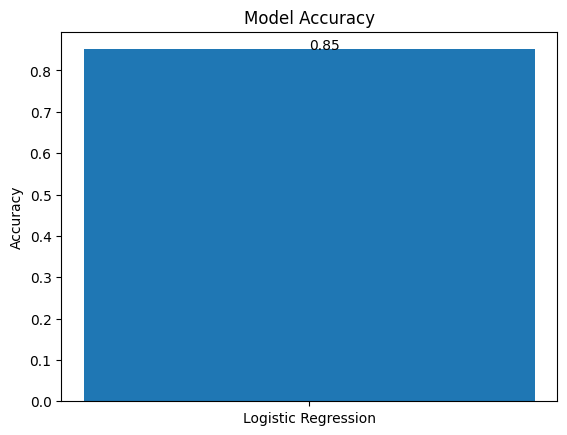

In [18]:
import matplotlib.pyplot as plt

plt.bar(["Logistic Regression"], [accuracy])

plt.text(0, accuracy, f"{accuracy:.2f}")

plt.ylabel("Accuracy")
plt.title("Model Accuracy")

plt.show()

In [19]:
print(classification_report(y_test, y_pred))

                       precision    recall  f1-score   support

               Access       0.92      0.86      0.89      1455
Administrative rights       0.87      0.67      0.76       342
           HR Support       0.85      0.84      0.85      2107
             Hardware       0.79      0.90      0.84      2760
     Internal Project       0.92      0.79      0.85       451
        Miscellaneous       0.82      0.83      0.82      1400
             Purchase       0.97      0.87      0.92       497
              Storage       0.94      0.83      0.88       556

             accuracy                           0.85      9568
            macro avg       0.89      0.82      0.85      9568
         weighted avg       0.86      0.85      0.85      9568



In [20]:
ticket = ["Payment deducted but order not placed"]

ticket_tfidf = vectorizer.transform(ticket)

prediction = model.predict(ticket_tfidf)

print(prediction)

['Hardware']


In [22]:
new_ticket = ["I am unable to login to my account"]

new_ticket_tfidf = vectorizer.transform(new_ticket)

prediction = model.predict(new_ticket_tfidf)

print("Predicted Category:", prediction[0])

Predicted Category: Access


In [23]:
import pickle

pickle.dump(model, open("ticket_classifier.pkl", "wb"))
pickle.dump(vectorizer, open("vectorizer.pkl", "wb"))

print("Model Saved Successfully")

Model Saved Successfully
